In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import torch
from datasets import Dataset
from setfit import SetFitModel
from setfit import SetFitTrainer

import re
import time
import requests
import trafilatura
from datetime import datetime, timedelta
from collections import defaultdict
import matplotlib.pyplot as plt
from urllib.parse import urlparse


In [ ]:


df = pd.read_csv("Test_Data.csv",index_col=False)
df["label"] = df["label"].astype(str).str.strip().str.lower()

#split model into train and test and cv - stratified 

train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42
)

#encode labels

label2id = {"down": 0, "neutral": 1, "up": 2}
id2label = {v: k for k, v in label2id.items()}

for df_part in [train_df, val_df, test_df]:
    df_part["label"] = df_part["label"].map(label2id)

#convert to hugging face datasets


train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds = Dataset.from_pandas(val_df[["text", "label"]])
test_ds = Dataset.from_pandas(test_df[["text", "label"]])

#load Setfit

model = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

#Train Setfit


trainer = SetFitTrainer(
    model=model,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    metric="f1",
    batch_size=16,
    num_iterations=20,   # how many contrastive steps
    num_epochs=1         # classifier training
)

trainer.train()


#eval model

preds = trainer.model(test_ds["text"])
true = test_ds["label"]

print("Accuracy:", accuracy_score(true, preds))
print("Macro F1:", f1_score(true, preds, average="macro"))



c:\Users\joven\miniconda3\envs\citadel\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
`SentenceTransformer._target_device` has been removed, please use `SentenceTransformer.device` instead.
model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


Generating Training Pairs:   0%|          | 0/20 [00:00<?, ?it/s]

***** Running training *****
  Num examples = 4360
  Num epochs = 1
  Total optimization steps = 273
  Total train batch size = 16


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration:   0%|          | 0/273 [00:00<?, ?it/s]

Accuracy: 0.7916666666666666
Macro F1: 0.7925925925925927


In [3]:

FINANCE_KEYWORDS = {
    "inflation", "cpi", "core inflation", "price pressures", "prices",
    "interest rate", "interest rates", "rate hike", "rate cut",
    "bank of england", "boe", "federal reserve", "fed", "ecb",
    "monetary policy", "tightening", "easing", "hawkish", "dovish",
    "wages", "labour market", "labor market", "consumer prices", "central bank"
}

SENTENCE_KEYWORDS = {
    "inflation", "cpi", "core inflation", "interest rate", "interest rates",
    "rate hike", "rate cut", "bank of england", "boe", "federal reserve", "fed",
    "ecb", "central bank", "monetary policy", "tightening", "easing",
    "hawkish", "dovish", "wages", "prices", "consumer prices",
    "sticky inflation", "services inflation", "disinflation"
}

FORWARD_LOOKING_KEYWORDS = {
    "expect", "expected", "expects", "forecast", "forecasts", "projected",
    "outlook", "likely", "unlikely", "could", "may", "might", "should",
    "anticipated", "anticipate", "signals", "signalled", "guidance"
}


def weighted_sentiment(probs,entropy):

    """
    probs: array of shape (n_sentences, 3)
        columns = [p_up, p_neutral, p_down]
    """

    #extract probs
    p_up = probs[:, 2]
    #p_neutral = probs[:, 1]  --- IGNORE ---
    p_down = probs[:, 0]

    #calculate score
    scores = p_up - p_down

    #normalise entropy
    H = entropy
    H_norm = H / np.log(3.0)

    #calculate weighted score 
    weights = np.abs(p_up - p_down) * (1 - H_norm)
    total_weights = np.sum(weights)

    #calculate weighted probabilities  
    weightedp_up = np.average(p_up, weights=weights) if total_weights > 0 else None
    weightedp_down = np.average(p_down, weights=weights) if total_weights > 0 else None
    
    if total_weights == 0:
            return 0.0, 0.0, 0.0, 0.0

    return np.sum(weights * scores) / total_weights, total_weights, weightedp_up, weightedp_down

#build rates expectations index - Ei = P_up - P_down, 

def rates_expectations(model, texts, labels=("down","neutral","up")):

    """
    Computes rate expectation scores from text using a SetFit model.

    Returns:
        dict with:
        - scores: per-text (p_up - p_down)
        - mean_score: aggregate expectation
        - probs: full probability matrix
        - predictions: predicted labels
        - confidence: confidence of predicted class
    """

    # Get probabilities
    probs = model.predict_proba(texts)

    #convert to numpy array 
    if isinstance(probs, torch.Tensor):
        probs = probs.detach().cpu().numpy()
    else:
        probs = np.asarray(probs)

    # Predictions + confidence
    pred_idx = np.argmax(probs, axis=1)
    predictions = [labels[i] for i in pred_idx]
    confidence = probs[np.arange(len(probs)), pred_idx]
    entropy = -np.sum(probs* np.log(probs + 1e-10), axis=1)

    text_sentiment_score, total_weights, weightedp_up, weightedp_down = weighted_sentiment(probs, entropy)

    values_dict = {
        "weighted_score": text_sentiment_score,
        "total_weights": total_weights,
        "entropy": entropy,
        "probs": probs,
        "predictions": predictions,
        "confidence": confidence,
        "weightedp_up": weightedp_up,
        "weightedp_down": weightedp_down
     }


    return text_sentiment_score,total_weights, values_dict

from turtle import title

import requests
import time

def fetch_gnews_articles(
    api_key,
    query,
    from_date=None,
    to_date=None,
    page_size=10,
    pages=1,
    language="en",
    search_in="title,description",
    sort_by="publishedAt"
):
    url = "https://gnews.io/api/v4/search"
    all_articles = []

    for page in range(1, pages + 1):
        params = {
            "q": query,
            "lang": language,
            "max": page_size,
            "page": page,
            "sortby": sort_by,
            "in": search_in,
            "apikey": api_key,
        }

        if from_date:
            params["from"] = from_date
        if to_date:
            params["to"] = to_date

        try:
            r = requests.get(url, params=params, timeout=20)
            r.raise_for_status()
        except requests.exceptions.ConnectionError as e:
            raise RuntimeError(
                "Network/DNS error reaching gnews.io. "
                "Check internet, DNS, VPN, firewall, or proxy settings."
            ) from e
        except requests.exceptions.HTTPError as e:
            print("HTTP status:", r.status_code)
            print("Response text:", r.text[:1000])
            raise

        data = r.json()
        articles = data.get("articles", [])
        all_articles.extend(articles)

        if len(articles) < page_size:
            break

        time.sleep(0.5)

    return all_articles


def extract_domain(url):
    if not url:
        return None
    netloc = urlparse(url).netloc.lower()
    if netloc.startswith("www."):
        netloc = netloc[4:]
    return netloc


def article_matches_domain(article, allowed_domains=None, blocked_domains=None):
    allowed_domains = set(d.lower() for d in (allowed_domains or []))
    blocked_domains = set(d.lower() for d in (blocked_domains or []))

    source_url = (article.get("source") or {}).get("url")
    article_url = article.get("url")

    domain = extract_domain(source_url) or extract_domain(article_url)
    if domain is None:
        return False

    def matches(domain, domain_list):
        return any(domain == d or domain.endswith("." + d) for d in domain_list)

    if allowed_domains and not matches(domain, allowed_domains):
        return False

    if blocked_domains and matches(domain, blocked_domains):
        return False

    return True


def is_financial_or_inflation_related(title, description=""):
    text = f"{title or ''} {description or ''}".lower()
    return any(keyword in text for keyword in FINANCE_KEYWORDS)


def extract_article_text(url):
    """
    Download and extract main article text using Trafilatura.
    Returns None if extraction fails.
    """
    downloaded = trafilatura.fetch_url(url)
    if not downloaded:
        return None

    text = trafilatura.extract(
        downloaded,
        favor_precision=True,
        include_comments=False
    )
    return text


def split_into_sentences(text):
    if not text:
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in sentences if s.strip()]


def sentence_score(sentence, title=""):
    """
    Score a sentence for relevance.
    Higher score = more likely useful for inflation / policy sentiment analysis.
    """
    s_lower = sentence.lower()
    title_lower = (title or "").lower()

    # basic keyword hits
    keyword_score = sum(kw in s_lower for kw in SENTENCE_KEYWORDS)

    # forward-looking language is often more useful for market sentiment
    forward_score = sum(kw in s_lower for kw in FORWARD_LOOKING_KEYWORDS)

    # overlap with title words
    title_words = set(re.findall(r"\b[a-z]{4,}\b", title_lower))
    sent_words = set(re.findall(r"\b[a-z]{4,}\b", s_lower))
    overlap_score = len(title_words & sent_words)

    # prefer medium-length sentences over tiny useless fragments
    word_count = len(sentence.split())
    if 8 <= word_count <= 40:
        length_score = 2
    elif 5 <= word_count <= 60:
        length_score = 1
    else:
        length_score = 0

    return (
        3 * keyword_score
        + 2 * forward_score
        + overlap_score
        + length_score
    )


def extract_key_sentences(text, title="", max_sentences=5, min_score=2):
    """
    Extract top-N relevant sentences from article text.
    """
    sentences = split_into_sentences(text)
    scored = []

    for i, s in enumerate(sentences):
        score = sentence_score(s, title=title)

        # slight preference for earlier sentences because journalists
        # keep pretending the important bit belongs near the top
        position_bonus = max(0, 2 - i * 0.1)
        total_score = score + position_bonus

        if total_score >= min_score:
            scored.append((total_score, s))

    scored.sort(key=lambda x: x[0], reverse=True)

    chosen = []
    seen = set()
    for _, s in scored:
        if s not in seen:
            chosen.append(s)
            seen.add(s)
        if len(chosen) >= max_sentences:
            break

    return chosen


def parse_article_day(article):
    published = article.get("publishedAt")
    if not published:
        return None
    # publishedAt usually looks like 2026-04-03T12:34:56Z
    return published[:10]


def default_sentiment_function(text):
    """
    Placeholder.
    Replace this with your trained model function.
    Should return a scalar score, e.g.:
      negative = -1
      neutral  = 0
      positive = +1
    or a continuous score.
    """
    return 0.0


def inter_article_directional_entropy(P_up, P_down, weights):
    P_up = np.array(P_up)
    P_down = np.array(P_down)
    weights = np.array(weights)

    total_weight = np.sum(weights)
    if total_weight == 0:
        return 0.0

    P_up_bar = np.sum(weights * P_up) / total_weight
    P_down_bar = np.sum(weights * P_down) / total_weight

    directional_mass = P_up_bar + P_down_bar
    if directional_mass <= 0:
        return 0.0

    p_up_dir = P_up_bar / directional_mass
    p_down_dir = P_down_bar / directional_mass

    probs = np.array([p_up_dir, p_down_dir])
    probs = np.clip(probs, 1e-12, 1.0)

    H = -np.sum(probs * np.log(probs))
    H_norm = H / np.log(2.0)

    return H_norm


def inter_article_entropy(P_up, P_down, weights):
    P_up = np.array(P_up)
    P_down = np.array(P_down)
    weights = np.array(weights)

    P_neutral = 1 - (P_up + P_down)

    total_weight = np.sum(weights)

    if total_weight == 0:
        return 0.0

    # weighted average probabilities
    P_up_bar = np.sum(weights * P_up) / total_weight
    P_down_bar = np.sum(weights * P_down) / total_weight
    P_neutral_bar = np.sum(weights * P_neutral) / total_weight

    probs = np.array([P_up_bar, P_neutral_bar, P_down_bar])
    probs = np.clip(probs, 1e-12, 1.0)

    H = -np.sum(probs * np.log(probs))
    H_norm = H / np.log(3.0)

    return H_norm


def weighted_variance(scores, weights):
    scores = np.array(scores)
    weights = np.array(weights)

    total_weight = np.sum(weights)

    if total_weight == 0:
        return 0.0

    mean = np.sum(weights * scores) / total_weight
    var = np.sum(weights * (scores - mean)**2) / total_weight

    return var


def build_daily_news_results(
    api_key,
    query,
    start_date,
    end_date,
    sentiment_fn=None,
    max_pages_per_day=1,
    page_size=50,
    max_sentences_per_article=7,
    domains=None,
    exclude_domains=None
):
    """
    Build results[day] dictionary:
      results[day]["articles"] -> list of processed article dicts
      results[day]["daily_sentiment_mean"] -> average sentiment of article snippets
      results[day]["n_articles"] -> number of usable articles
    """
    if sentiment_fn is None:
        sentiment_fn = default_sentiment_function

    results = defaultdict(lambda: {
        "articles": [],
        "daily_sentiment_score": None,
        "weighted_daily_sentiment_score": None,
        "n_articles": 0,
        "inter_article_entropy": None,
        "inter_article_directional_entropy": None,
        "weighted_variance": None
    })

    start_dt = datetime.strptime(start_date, "%Y-%m-%d")
    end_dt = datetime.strptime(end_date, "%Y-%m-%d")

    current = start_dt
    while current <= end_dt:
        day_str = current.strftime("%Y-%m-%d")
        from_ts = current.strftime("%Y-%m-%dT00:00:00Z")
        next_day_ts = (current + timedelta(days=1)).strftime("%Y-%m-%dT00:00:00Z")

        # Fetch one day at a time to control quota and keep clean time series
        raw_articles = fetch_gnews_articles(
            api_key=api_key,
            query=query,
            from_date=from_ts,
            to_date=next_day_ts,
            page_size=page_size,
            pages=max_pages_per_day,
            language="en",
            search_in="title,description",
        
            sort_by="publishedAt"
        )

        # Cheap metadata filter before full-text extraction
        filtered_articles = []
        seen_urls = set()
        seen_titles = set()

        for article in raw_articles:

            url = article.get("url")

            if not url or url in seen_urls:
                continue
            

            title = (article.get("title") or "").strip().lower()

            if title in seen_titles:
                 continue

            
            seen_urls.add(url)
            seen_titles.add(title)

            title = article.get("title", "")
            desc = article.get("description", "")

            # domain filter
            if not article_matches_domain(
                article,
                allowed_domains=domains,
                blocked_domains=exclude_domains
            ):
                continue

            # keyword filter
            if is_financial_or_inflation_related(title, desc):
                filtered_articles.append(article)

        #create empty arrays to hold article sentiment scores, article weighted probabilities and weights for aggregation later
        article_sentiment_scores = np.array([])
        article_weights = np.array([])
        article_P_up = np.array([])
        article_P_down = np.array([])

        #l
        for article in filtered_articles:
            title = article.get("title", "")
            url = article.get("url", "")
            source = (article.get("source") or {}).get("name")
            published_at = article.get("publishedAt")

            text = extract_article_text(url)
            if not text:
                continue

            key_sentences = extract_key_sentences(
                text,
                title=title,
                max_sentences=max_sentences_per_article
            )

            if not key_sentences:
                continue

            #sentiment score per article and article weight score based on confidence and entropy of sentence predictions
            article_sentiment_score, article_weight, dict_val = sentiment_fn(model,key_sentences)

            #add article scores, weights and probabilities to arrays for later aggregation
            article_sentiment_scores = np.append(article_sentiment_scores, article_sentiment_score)
            article_weights = np.append(article_weights, article_weight)
            article_P_up = np.append(article_P_up, dict_val.get("weightedp_up", 0))
            article_P_down = np.append(article_P_down, dict_val.get("weightedp_down", 0))


            #add key articles information to results dict for the day 
            results[day_str]["articles"].append({
                "title": title,
                "url": url,
                "source": source,
                "publishedAt": published_at,
                "key_sentences": key_sentences,
                "sentiment_score": article_sentiment_score,
                "article_weight": article_weight
            })


        #calculate amount of articles for the day 
        results[day_str]["n_articles"] = len(results[day_str]["articles"])



        #calculate weighted daily sentiment scores using article sentiment scores and weights
        weighted_daily_sentiment_score = np.average(article_sentiment_scores, weights=article_weights) if article_weights.size > 0 else None
        
        if article_sentiment_scores.size > 0:
            results[day_str]["daily_sentiment_score"] = np.mean(article_sentiment_scores)

        results[day_str]["weighted_daily_sentiment_score"] = weighted_daily_sentiment_score


        #ENTROPY CALCULATION
        #calculate inter-article entropy as a measure of disagreement among article sentiments

        if article_P_up.size > 0 and article_P_down.size > 0 and article_weights.size > 0:
            inter_article_ent = inter_article_entropy(article_P_up, article_P_down, article_weights)
            results[day_str]["inter_article_entropy"] = inter_article_ent

        # calculate inter-article directional entropy

            inter_article_dir_ent = inter_article_directional_entropy(article_P_up, article_P_down, article_weights)
            results[day_str]["inter_article_directional_entropy"] = inter_article_dir_ent
            
        #calculate weighted variance of article sentiment scores as another measure of disagreement         
        if article_sentiment_scores.size > 0 and article_weights.size > 0:
            weighted_var = weighted_variance(article_sentiment_scores, article_weights)
            results[day_str]["weighted_variance"] = weighted_var

        current += timedelta(days=1)

    return dict(results)

In [ ]:
NEWSAPI_KEY = "18bd50fe1d86717323930bfda51d2f14"
#NEWSAPI_KEY = "d229ea6ffc58476f91acb9c22dd9566f"

QUERY = (
    '("inflation" OR "CPI" OR "core inflation" OR "interest rates" '
    'OR "rate hike" OR "rate cut" OR "monetary policy" '
    'OR "central bank" OR "Bank of England" OR "Federal Reserve" OR "ECB")'
)

TRUSTED_DOMAINS = [
    # Tier 1: Institutions
    "bankofengland.co.uk",
    "federalreserve.gov",
    "ecb.europa.eu",
    "imf.org",
    "oecd.org",
    "bis.org",
    "treasury.gov",
    "hm-treasury.gov.uk",

    # Tier 2: Financial journalism
    "reuters.com",
    "ft.com",
    "bloomberg.com",
    "wsj.com",
    "economist.com",
    "marketwatch.com",
    "finance.yahoo.com",
    "nikkei.com",
    "financialpost.com",
    "thetimes.co.uk",
    "businessinsider.com",

    # Tier 3: General high-quality news
    "bbc.co.uk",
    "nytimes.com",
    "washingtonpost.com",
    "theglobeandmail.com",

    # Tier 4: Market-facing
    "cnbc.com",
    "barrons.com",
    "seekingalpha.com",
    "investing.com",
    "fxstreet.com",
    "kitco.com"
]

UK_DOMAINS = [
    # --- UK institutions (ground truth) ---
    "bankofengland.co.uk",
    "hm-treasury.gov.uk",
    "ons.gov.uk",
    "obr.uk",

    # --- Global institutions (keep, they matter for UK macro) ---
    "federalreserve.gov",
    "ecb.europa.eu",
    "imf.org",
    "oecd.org",
    "bis.org",

    # --- Top-tier financial news (core signal) ---
    "ft.com",
    "bloomberg.com",
    "reuters.com",
    "wsj.com",
    "economist.com",

    # --- UK financial / economic coverage ---
    "thetimes.co.uk",
    "telegraph.co.uk",
    "cityam.com",
    "economicsobservatory.com",
    "capitaleconomics.com",

    # --- UK general news (policy + narrative) ---
    "bbc.co.uk",
    "theguardian.com",
    "independent.co.uk",
    "sky.com",
    "itv.com/news",
    "channel4.com/news",

    # --- Markets / rates expectations layer ---
    "cnbc.com",
    "marketwatch.com",
    "finance.yahoo.com",
    "investing.com",
    "fxstreet.com",

    # --- Optional but valuable macro research tone ---
    "goldmansachs.com",
    "jpmorgan.com",
    "hsbc.com",
    "barclays.co.uk",
    "natwestgroup.com"
]

#Reality layer → BoE, ONS
#Interpretation layer → FT, Bloomberg, Reuters
#Expectation layer → FXStreet, CNBC
#Narrative/politics leakage → BBC, Guardian, Times

results = build_daily_news_results(
    api_key=NEWSAPI_KEY,
    query=QUERY,
    start_date="2025-09-11",
    end_date="2026-04-20",
    sentiment_fn=rates_expectations,
    max_pages_per_day=5,
    page_size=100,
    max_sentences_per_article=7,
    domains=TRUSTED_DOMAINS
)

NameError: name 'build_daily_news_results' is not defined

In [ ]:


results_df = pd.DataFrame(results)

#print sum of articles row to check total number of articles collected across all days
print(results_df.loc["n_articles"].sum())

# add 6-day rolling average of daily sentiment score and weighted daily sentiment score
results_df.loc["daily_sentiment_score_6d_avg"] = (
    results_df.loc["daily_sentiment_score"].rolling(window=6, min_periods=1).mean()
)

results_df.loc["weighted_daily_sentiment_score_6d_avg"] = (
    results_df.loc["weighted_daily_sentiment_score"].rolling(window=6, min_periods=1).mean()
)


#save results to csv
#results_df.to_csv("uk_sentiment_results.csv")

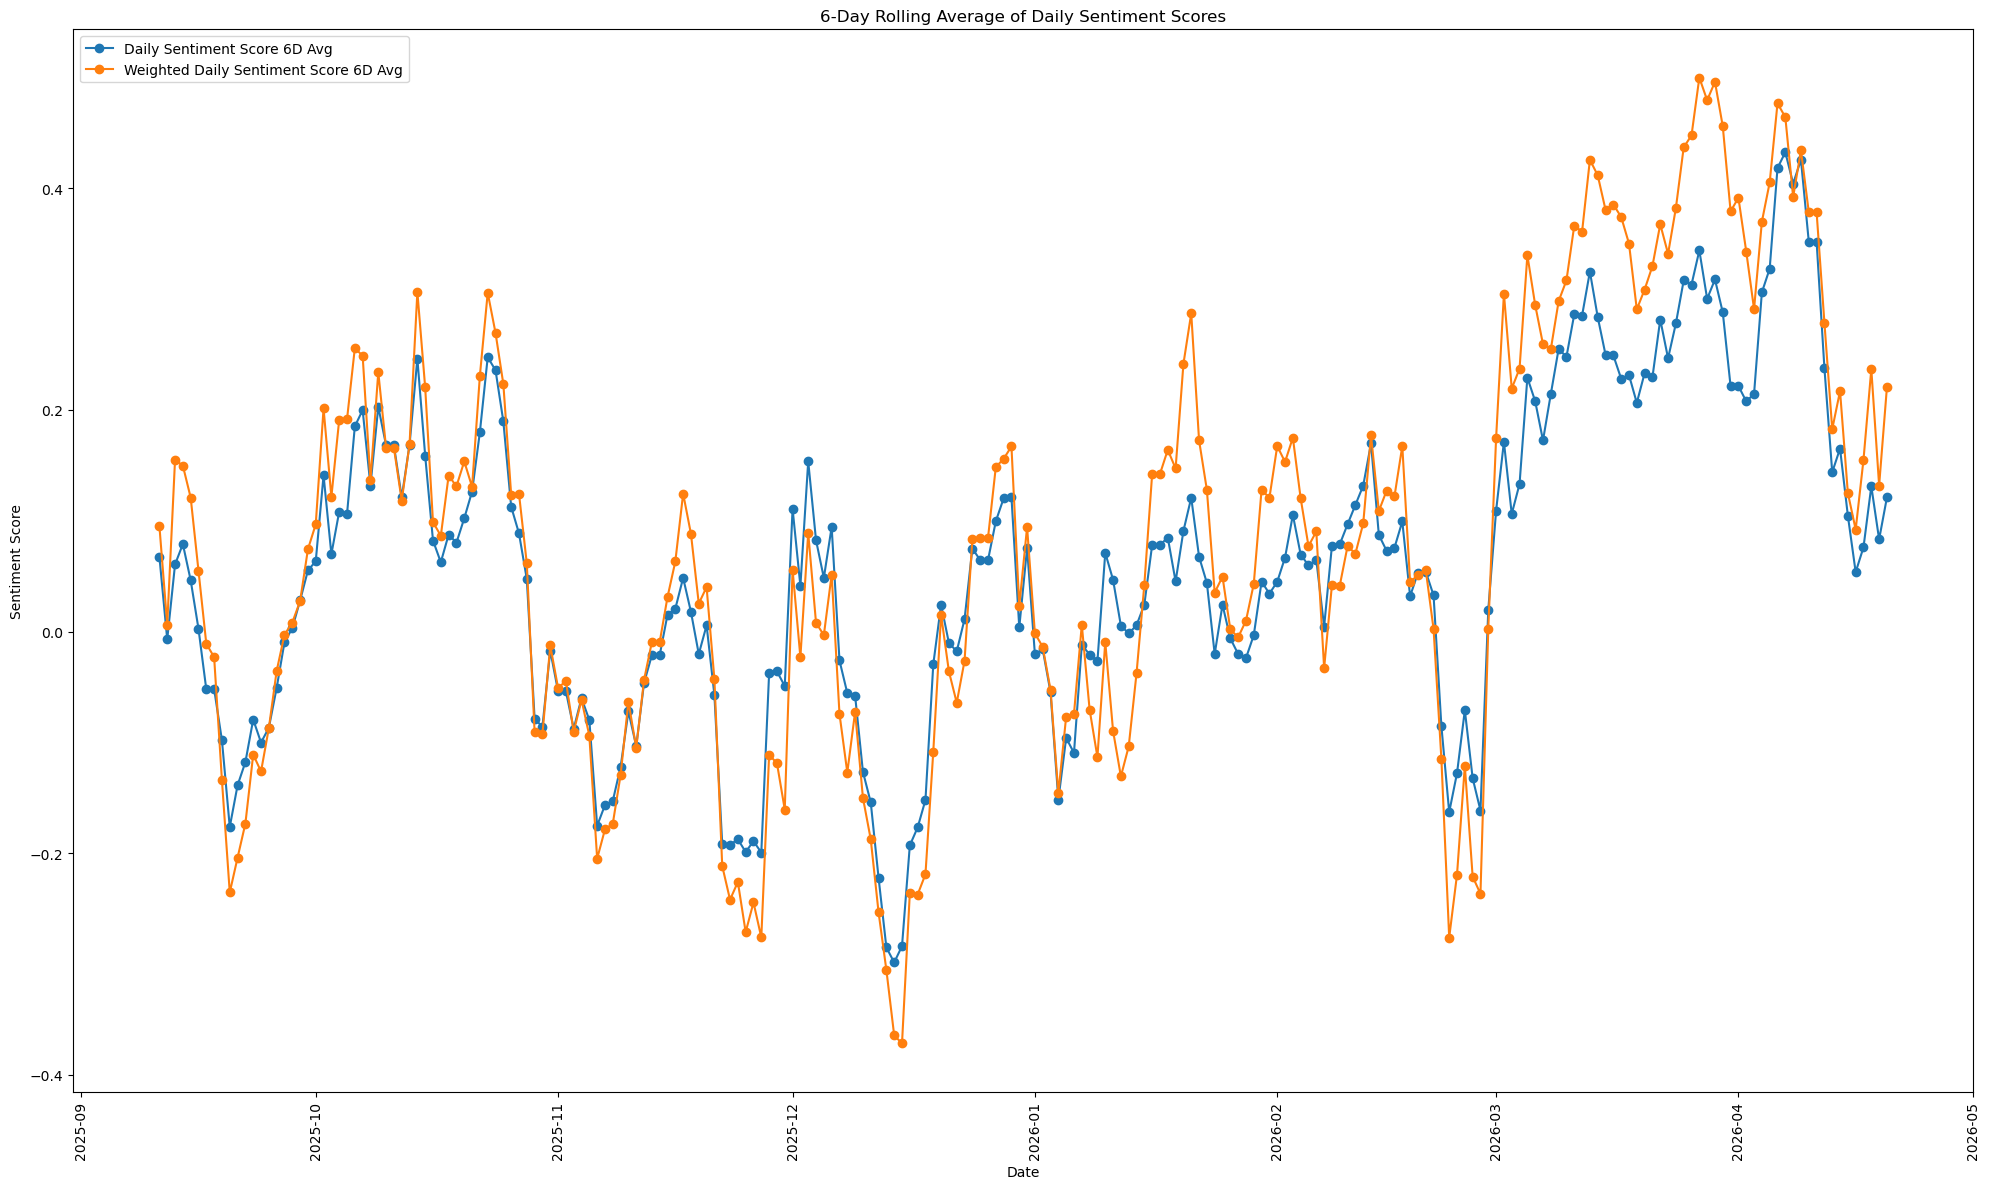

In [3]:
#slice results from csv and plot daily sentiment score and weighted daily sentiment score with 6-day rolling average for the period
results_df = pd.read_csv(r"C:\Users\joven\Documents\ML Projects\Citadel-Fixed-Income-Challenge---Sentiment-Analysis\csv_data\uk_sentiment_results.csv", index_col=0) #UK Results
#results_df = pd.read_csv(r"Citadel-Fixed-Income-Challenge---Sentiment-Analysis\csv_data\main_results.csv", index_col=0) Main Results

numeric_rows = [
    "daily_sentiment_score",
    "weighted_daily_sentiment_score",
    "n_articles",
    "inter_article_entropy",
    "inter_article_directional_entropy",
    "weighted_variance",
    "daily_sentiment_score_6d_avg",
    "weighted_daily_sentiment_score_6d_avg",
]

numeric_df = results_df.loc[numeric_rows].apply(pd.to_numeric, errors="coerce")

x = pd.to_datetime(numeric_df.columns)
y1 = numeric_df.loc["daily_sentiment_score_6d_avg"]
y2 = numeric_df.loc["weighted_daily_sentiment_score_6d_avg"]

plt.figure(figsize=(20, 12))
plt.plot(x, y1, label="Daily Sentiment Score 6D Avg", marker='o')
plt.plot(x, y2, label="Weighted Daily Sentiment Score 6D Avg", marker='o')
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.title("6-Day Rolling Average of Daily Sentiment Scores")
plt.legend()
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


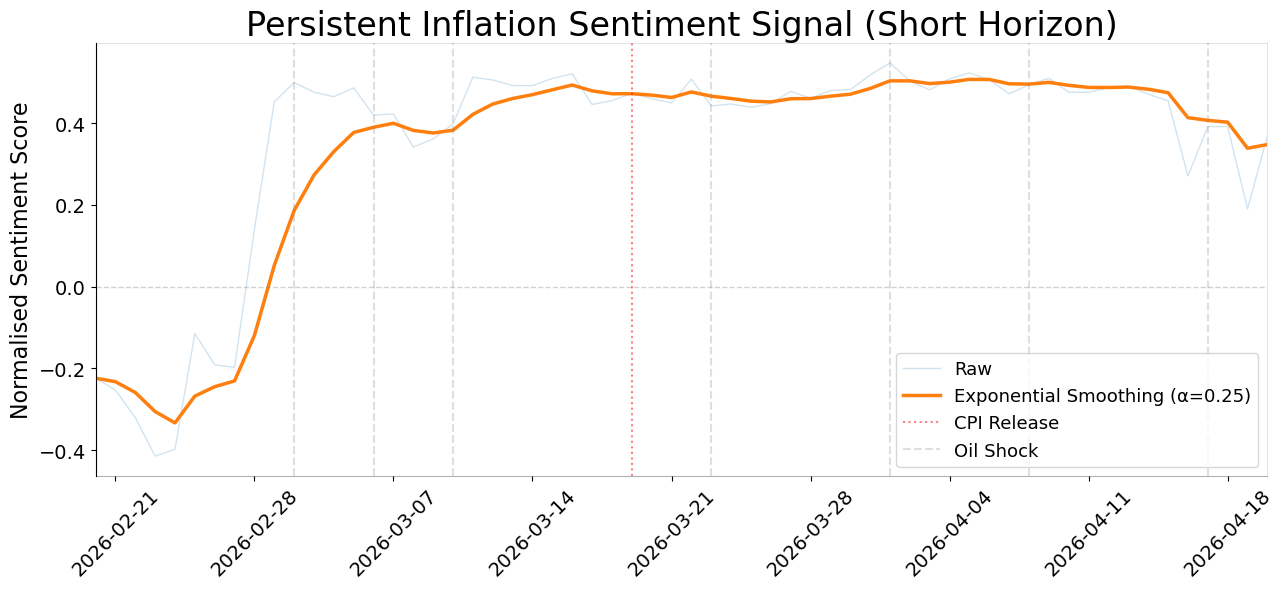

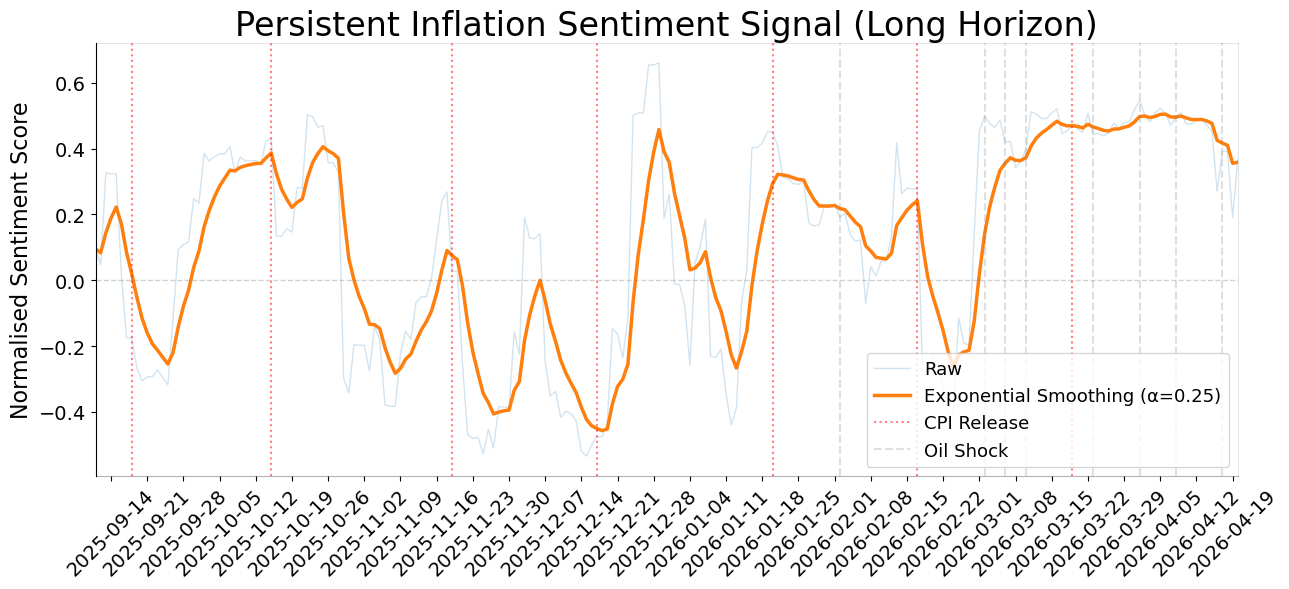

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from statsmodels.nonparametric.smoothers_lowess import lowess


# =========================================================
# 1. Confidence-weighted rolling average
# =========================================================
def add_confidence_weighted_rolling(
    df,
    score_row="daily_sentiment_score",
    entropy_row="inter_article_entropy",
    count_row="n_articles",
    window=6,
    new_row_name="confidence_weighted_rolling"
):
    """
    Adds a confidence-weighted rolling average row to results_df.

    Weight = n_articles * (1 - entropy)
    """

    scores = df.loc[score_row].astype(float).values
    entropy = df.loc[entropy_row].astype(float).values
    counts = df.loc[count_row].astype(float).values

    # Replace NaNs safely
    entropy = np.nan_to_num(entropy, nan=1.0)   # max entropy -> zero confidence
    counts = np.nan_to_num(counts, nan=0.0)
    scores = np.nan_to_num(scores, nan=0.0)

    confidence = 1 - entropy
    weights = counts * confidence

    rolling_vals = []

    for i in range(len(scores)):
        start = max(0, i - window + 1)
        v = scores[start:i+1]
        w = weights[start:i+1]

        w_sum = np.sum(w)
        if w_sum == 0:
            rolling_vals.append(np.nan)
        else:
            rolling_vals.append(np.sum(v * w) / w_sum)

    df.loc[new_row_name] = rolling_vals
    return df


# =========================================================
# 2. Build results_df properly
# =========================================================
results_df_fixed = results_df.copy()

results_df_fixed = add_confidence_weighted_rolling(
    results_df_fixed,
    window=6,
    new_row_name="confidence_weighted_6d_avg"
)

results_df_fixed = add_confidence_weighted_rolling(
    results_df_fixed,
    score_row="weighted_daily_sentiment_score",
    entropy_row="inter_article_directional_entropy",
    count_row="n_articles",
    window=6,
    new_row_name="confidence_weighted_weighted_6d_avg"
)


# =========================================================
# 3. Prepare long / short horizon data
# =========================================================
dates = pd.to_datetime(results_df_fixed.columns)
y = results_df_fixed.loc["confidence_weighted_weighted_6d_avg"].astype(float).values

# Sort long horizon
order = np.argsort(dates)
dates = dates[order]
y = y[order]

# Recent window
recent_results_df = results_df_fixed.iloc[:, -60:]
recent_dates = pd.to_datetime(recent_results_df.columns)
y_recent = recent_results_df.loc["confidence_weighted_weighted_6d_avg"].astype(float).values

# Sort recent horizon properly
recent_order = np.argsort(recent_dates)
recent_dates = recent_dates[recent_order]
y_recent = y_recent[recent_order]


# =========================================================
# 4. Smoothing helpers
# =========================================================
def exp_smooth(y, alpha=0.25):
    y = np.asarray(y, dtype=float)
    s = np.zeros_like(y, dtype=float)

    if len(y) == 0:
        return s

    # handle leading NaN safely
    first_valid_idx = np.where(~np.isnan(y))[0]
    if len(first_valid_idx) == 0:
        return np.full_like(y, np.nan, dtype=float)

    first_idx = first_valid_idx[0]
    s[:] = np.nan
    s[first_idx] = y[first_idx]

    for i in range(first_idx + 1, len(y)):
        if np.isnan(y[i]):
            s[i] = s[i - 1]
        else:
            s[i] = alpha * y[i] + (1 - alpha) * s[i - 1]

    return s


y_exp = exp_smooth(y, alpha=0.25)
y_exp_recent = exp_smooth(y_recent, alpha=0.3)


# =========================================================
# 5. Macro event data
# =========================================================
cpi_releases = pd.to_datetime([
    "2025-09-18",
    "2025-10-15",
    "2025-11-19",
    "2025-12-17",
    "2026-01-20",
    "2026-02-17",
    "2026-03-19",
])

boe_meetings = pd.to_datetime([
    "2025-09-18",
    "2025-11-06",
    "2025-12-18",
    "2026-02-05",
    "2026-03-19",
])

oil = yf.download("BZ=F", start="2025-09-01", end="2026-04-30", auto_adjust=False)

# Handle multi-index columns if yfinance returns them
if isinstance(oil.columns, pd.MultiIndex):
    oil.columns = oil.columns.get_level_values(0)

oil["returns"] = oil["Close"].pct_change()

# Keep only large absolute moves
shocks = oil[oil["returns"].abs() > 0.05].copy()
shocks = shocks.reindex(shocks["returns"].abs().sort_values(ascending=False).index)

# Pick top 3 distinct-ish shocks (at least 7 days apart)
selected_shocks = []
for dt in shocks.index:
    if not any(abs((dt - prev).days) < 3 for prev in selected_shocks):
        selected_shocks.append(dt)
    if len(selected_shocks) == 8:
        break

top_shocks = pd.to_datetime(selected_shocks)


# =========================================================
# 6. Plot formatting helper
# =========================================================
def style_macro_ax(ax, xmin, xmax, ylabel=True, add_boe=False):
    ax.set_xlim(xmin, xmax)
    ax.axhline(0, color="grey", linestyle="--", linewidth=1, alpha=0.35)

    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_alpha(0.3)
    ax.spines["top"].set_alpha(0.1)
    ax.spines["right"].set_alpha(0.1)

    ax.tick_params(axis="x", labelbottom=True, rotation=45, labelsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))

    # CPI lines
    cpi_label_added = False
    for date in cpi_releases:
        if xmin <= date <= xmax:
            ax.axvline(
                date,
                linestyle=":",
                color="red",
                alpha=0.5,
                label="CPI Release" if not cpi_label_added else ""
            )
            cpi_label_added = True

    # Oil shocks
    oil_label_added = False
    for date in top_shocks:
        if xmin <= date <= xmax:
            ax.axvline(
                date,
                linestyle="--",
                color="grey",
                alpha=0.25,
                label="Oil Shock" if not oil_label_added else ""
            )
            oil_label_added = True

    # Optional: BoE meetings
    if add_boe:
        boe_label_added = False
        for date in boe_meetings:
            if xmin <= date <= xmax:
                ax.axvline(
                    date,
                    linestyle="-.",
                    color="black",
                    alpha=0.25,
                    label="BoE Meeting" if not boe_label_added else ""
                )
                boe_label_added = True

    if ylabel:
        ax.set_ylabel("Normalised Sentiment Score", fontsize=16)


# =========================================================
# 7. SHORT HORIZON FIGURE
# =========================================================
fig_short, ax_short = plt.subplots(figsize=(13,6))

ax_short.plot(
    recent_dates,
    y_recent,
    alpha=0.20,
    linewidth=1,
    label="Raw"
)
ax_short.plot(
    recent_dates,
    y_exp_recent,
    linewidth=2.5,
    label="Exponential Smoothing (α=0.25)"
)

ax_short.set_title("Persistent Inflation Sentiment Signal (Short Horizon)", fontsize=24)
style_macro_ax(ax_short, recent_dates.min(), recent_dates.max(), add_boe=False)
ax_short.legend(loc="lower right", fontsize=13)

fig_short.tight_layout()
plt.show()


# =========================================================
# 8. LONG HORIZON FIGURE
# =========================================================
fig_long, ax_long = plt.subplots(figsize=(13, 6))

ax_long.plot(
    dates,
    y,
    alpha=0.20,
    linewidth=1,
    label="Raw"
)
ax_long.plot(
    dates,
    y_exp,
    linewidth=2.5,
    label="Exponential Smoothing (α=0.25)"
)

ax_long.set_title("Persistent Inflation Sentiment Signal (Long Horizon)", fontsize=24)
style_macro_ax(ax_long, dates.min(), dates.max(), add_boe=False)
ax_long.legend(loc="lower right", fontsize=13)

fig_long.tight_layout()
plt.show()

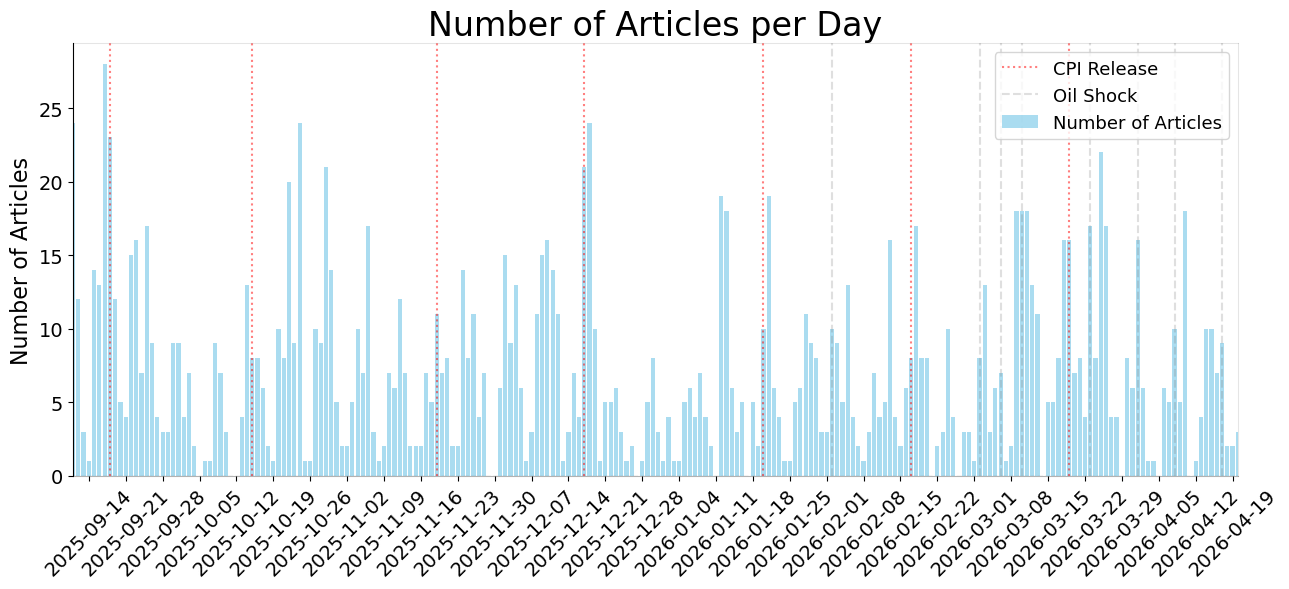

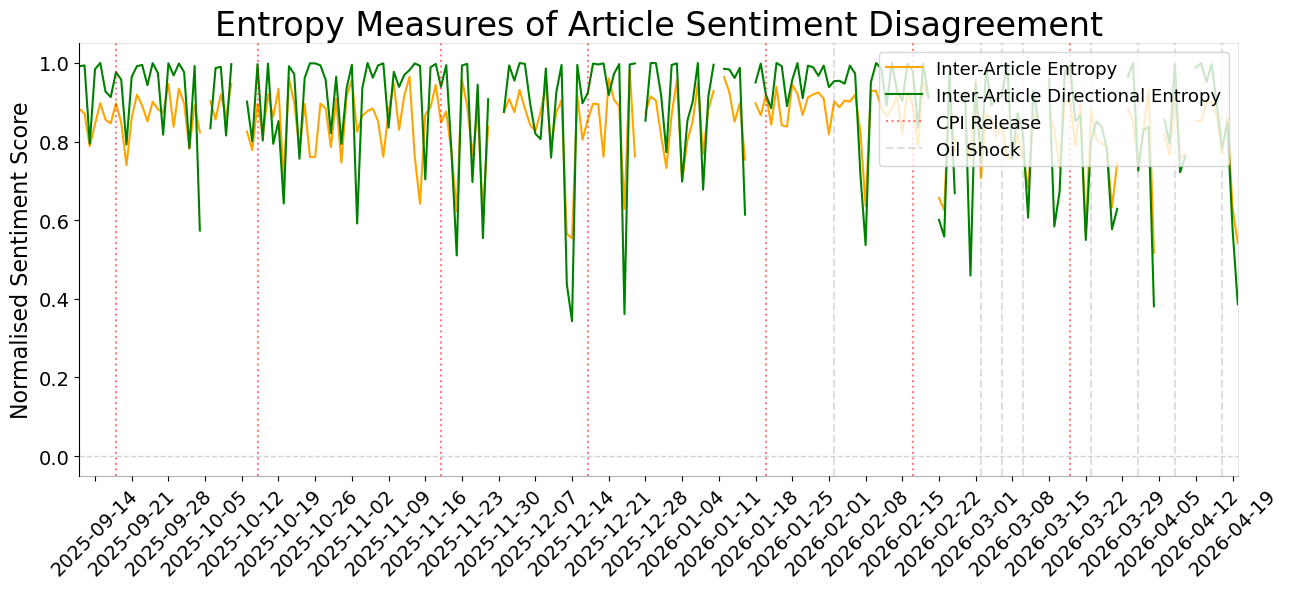

In [14]:
#plot num of articles per day as bar chart with cpi release dates and oil shock dates marked as vertical lines
fig_articles, ax_articles = plt.subplots(figsize=(13, 6))   
article_counts = results_df_fixed.loc["n_articles"].astype(float).values
ax_articles.bar(dates, article_counts, color="skyblue", alpha=0.7, label="Number of Articles")
style_macro_ax(ax_articles, dates.min(), dates.max(), ylabel="Number of Articles", add_boe=False)
ax_articles.set_ylabel("Number of Articles", fontsize=16)
ax_articles.set_title("Number of Articles per Day", fontsize=24)   
ax_articles.legend(loc="upper right", fontsize=13)
fig_articles.tight_layout()      
plt.show()

#plot entropy measures over time
fig_entropy, ax_entropy = plt.subplots(figsize=(13, 6))
inter_article_entropy = results_df_fixed.loc["inter_article_entropy"].astype(float).values
inter_article_dir_entropy = results_df_fixed.loc["inter_article_directional_entropy"].astype(float).values  
ax_entropy.plot(dates, inter_article_entropy, label="Inter-Article Entropy", color="orange")
ax_entropy.plot(dates, inter_article_dir_entropy, label="Inter-Article Directional Entropy", color="green") 
style_macro_ax(ax_entropy, dates.min(), dates.max(), ylabel="Entropy", add_boe=False)
ax_entropy.set_title("Entropy Measures of Article Sentiment Disagreement", fontsize=24)
ax_entropy.legend(loc="upper right", fontsize=13)
fig_entropy.tight_layout()
plt.show()

In [23]:
results_df["2025-09-11"]["articles"]

'[{\'title\': \'Wall Street rallies as a cut to interest rates next week looks more certain\', \'url\': \'https://www.latimes.com/business/story/2025-09-11/wall-street-rallies-as-a-cut-to-interest-rates-next-week-looks-more-certain\', \'source\': \'Los Angeles Times\', \'publishedAt\': \'2025-09-11T21:01:34Z\', \'key_sentences\': [\'Wall Street rallies as a cut to interest rates next week looks more certain\\n-\\nClick here to listen to this article\\n-\\n-\\nWall Street’s record-setting run kept rolling Thursday, and stocks climbed after a mixed set of U.S.\', \'The Fed has been hesitant to cut interest rates throughout 2025 because of the threat that President Trump’s tariffs could worsen inflation.\', \'data kept the path clear for the Federal Reserve to cut interest rates in order to boost the economy.\', \'The job market has to be weak enough to get the Fed to cut interest rates, which can give a kickstart to the economy and to prices for investments, but not so much that it cause